## Lasso Regression

### Why Ridge Regression is not enough?
Ridge regression solves Linear regression problem by decreasing coefficient values but it don't mamke them zero. Even if we have any useless features, it doesn't make them zero. Suppose if we have a feature as Owner Phone Number in our dataset, naturally this feature doesn't affect the Price of House but still Linear and Ridge regression gives them some value, but not zero.

### Why Lasso Regression invented?
Ridge keeps every feature even useless one but Lasso keeps a feature only if it affects the target, if a feature is useless it makes it's coefficient value exactly zero. Now the model completely ignores those features. This introduces **Feature Selection" concept. Feature Selection is the process of identifying and keeping only the most important input features while removing unnecessary ones. Lasso performs automatic feature selection. This is the biggest advantage. However, this is only useful for dataset having useless features otherwise it will be same as Ridge. Lasso Regression was developed to perform regularization while also automatically selecting important features by reducing some coefficients exactly to zero.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import joblib

In [2]:
# Load dataset
df = pd.read_csv("../data/housing.csv")
# Remove address - RR also expects numerical input
df = df.drop("Address", axis=1)

In [3]:
# Explore data same as in LR like head() describe() etc.
# Feature selection and seperating data
X = df.drop("Price", axis=1)
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
lasso_model = Lasso(alpha=1.0)

In [5]:
# Train data
lasso_model.fit(X_train, y_train)
# Test data
y_pred = lasso_model.predict(X_test)
for actual, pred in list(zip(y_test[:5], y_pred[:5])):
    print("Actual :", actual, "Predicted: ", pred)

Actual : 1339096.077 Predicted:  1308587.526220203
Actual : 1251794.179 Predicted:  1237036.6185594578
Actual : 1340094.966 Predicted:  1243429.5289421221
Actual : 1431507.623 Predicted:  1228899.1000191732
Actual : 1042373.524 Predicted:  1063324.403058113


In [6]:
# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 80879.15941364793
RMSE: 100444.12076263705
R² : 0.9179970723807351


### Comparison
R square is same as Ridge -> this means our dataset has no useless features 

In [7]:
joblib.dump(lasso_model, "../models/lasso_model.joblib")

['../models/lasso_model.joblib']

In [8]:
# Inspecting coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

coefficients

,Feature,Coefficient
0,Avg. Area Income,21.652206
1,Avg. Area House Age,164665.458559
2,Avg. Area Number of Rooms,119623.219690
3,Avg. Area Number of Bedrooms,2440.020133
4,Area Population,15.270310


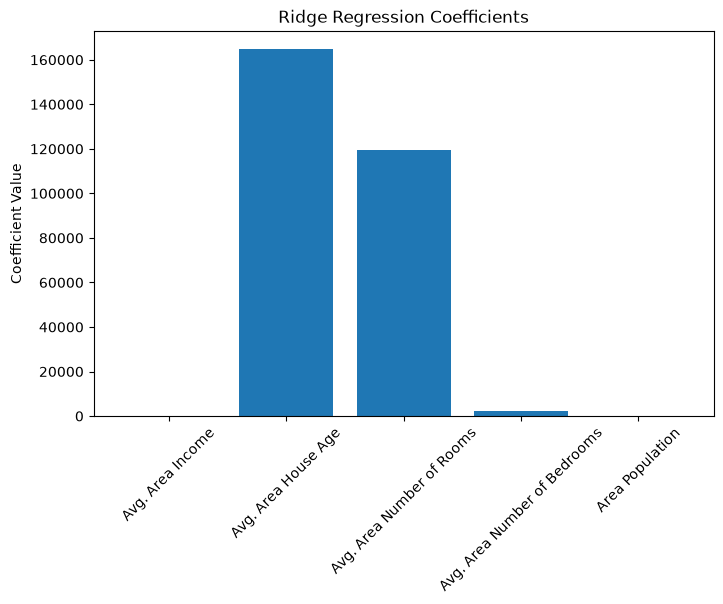

In [9]:
# Plot Coefficient
feature_names = X.columns
plt.figure(figsize=(8,5))

plt.bar(feature_names, lasso_model.coef_)

plt.xticks(rotation=45)
plt.title("Ridge Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

If any coefficient became 0 that means Lasso removed them.  
But here nothing become zero because all the features we have in our datset contribute to price. This is not a failure of Lasso. Lasso just don't have any reason to remove them.